In [2]:
!pip install pandas scikit-learn sentence-transformers rapidfuzz langdetect matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 18.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 67.1 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=63ff1327e2ee9474044ff6bd1ce415952195aae58efd9bb7829ac503107fba0b
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [3]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from rapidfuzz import process as rf_process, fuzz as rf_fuzz
from langdetect import detect
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime

In [6]:
# ---------- Helper functions ----------
def clean_text(s):
    if pd.isna(s):
        return ""
    s = str(s)
    s = s.strip()
    s = re.sub(r'\s+', ' ', s)
    s = re.sub(r'[\r\n]+', ' ', s)
    return s

def normalize_for_matching(s):
    s = clean_text(s).lower()
    s = re.sub(r'[^a-z0-9\s]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

In [17]:
# ---------- Helper functions ----------
def clean_text(s):
    if pd.isna(s):
        return ""
    s = str(s)
    s = s.strip()
    s = re.sub(r'\s+', ' ', s)
    s = re.sub(r'[\r\n]+', ' ', s)
    return s

def normalize_for_matching(s):
    s = clean_text(s).lower()
    s = re.sub(r'[^a-z0-9\s]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

# ---------- Load files ----------
emails = pd.read_csv("/content/customer_emails.csv", on_bad_lines='skip')

   # expects columns: email_id, date, from, subject, body

products= pd.read_csv("/content/product_catalog.csv", on_bad_lines='skip')

# expects: product_id, name, description, price, stock, category, tags

# Basic cleaning
emails['Subject'] = emails['Subject'].fillna('').map(clean_text)
emails['Message Content'] = emails['Message Content'].fillna('').map(clean_text)
emails['combined'] = (emails['Subject'] + ' ' + emails['Message Content']).map(clean_text)

products['Name'] = products['Name'].fillna('').map(clean_text)
products['Description'] = products['Description'].fillna('').map(clean_text)
products['full_text'] = (products['Name'] + ' . ' + products['Description']).map(clean_text)

In [18]:
# ---------- Language detection (optional) ----------
def detect_lang_safe(text):
    try:
        return detect(text)
    except:
        return 'en'
emails['lang'] = emails['combined'].apply(detect_lang_safe)

In [19]:
# Use a compact model for speed: "all-MiniLM-L6-v2" (English). For multilingual, use a multilingual model.
model = SentenceTransformer('all-MiniLM-L6-v2')   # download first time; replace for multilingual if needed

product_texts = products['full_text'].tolist()
product_embs = model.encode(product_texts, convert_to_numpy=True, show_progress_bar=True, batch_size=32)

email_texts = emails['combined'].tolist()
email_embs = model.encode(email_texts, convert_to_numpy=True, show_progress_bar=True, batch_size=32)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [48]:
def match_email_to_products(email_idx, top_k=3):
    e_emb = email_embs[email_idx].reshape(1, -1)
    sims = cosine_similarity(e_emb, product_embs).ravel()
    top_idx = sims.argsort()[::-1][:top_k]
    results = []
    for idx in top_idx:
        results.append({
            'product_idx': int(idx),
            'Product ID': products.iloc[idx]['Product ID'],
            'name': products.iloc[idx]['Name'],
            'score': float(sims[idx])
        })
    return results

In [49]:
# ---------- Fuzzy fallback (if needed) ----------
product_names_normalized = products['Name'].apply(normalize_for_matching).tolist()
def fuzzy_match_query(query, limit=3):
    q = normalize_for_matching(query)
    choices = product_names_normalized
    matches = rf_process.extract(q, choices, scorer=rf_fuzz.token_sort_ratio, limit=limit)
    # matches are tuples (choice, score, index)
    return [{'product_idx': int(idx), 'Product ID': products.iloc[idx]['Product ID'],
             'name': products.iloc[idx]['Name'], 'score': score/100.0} for choice, score, idx in matches]

In [58]:
def generate_response(email_row, matches, confidence_threshold=0.55, tone='polite'):
    # --- Greeting tone ---
    if tone == 'casual':
        greeting = f"Hi {email_row.get('Customer Name', '')},".strip()
    elif tone == 'formal':
        greeting = f"Dear {email_row.get('Customer Name', 'Customer')},"
    else:
        greeting = f"Hello {email_row.get('Customer Name', '')},".strip()

    opening = f"{greeting}\n\nThank you for contacting us."

    body_lines = []
    best = matches[0]

    # --- If confident match ---
    if best['score'] >= confidence_threshold:
        prod = products.iloc[best['product_idx']]
        stock = prod.get('Stock Status', 'Unknown')
        price = prod.get('Price', 'N/A')
        desc = prod.get('Description', '')

        body_lines.append(
            f"We believe you are asking about *{prod['Name']}*.\n"
            f"Price: {price}, Availability: {stock}.\n"
            f"{desc}"
        )

        # If confidence not super high → show alternatives too
        if best['score'] < 0.75 and len(matches) > 1:
            alt_lines = []
            for alt in matches[1:]:
                alt_prod = products.iloc[alt['product_idx']]
                alt_lines.append(
                    f"- {alt_prod['Name']} (confidence {alt['score']:.2f}) — "
                    f"Price: {alt_prod.get('Price','N/A')}, Stock: {alt_prod.get('Stock Status','Unknown')}"
                )
            if alt_lines:
                body_lines.append(
                    "\nIf this is not the product you meant, here are some alternatives:\n"
                    + "\n".join(alt_lines)
                )

    # --- If no confident match ---
    else:
        body_lines.append("We couldn't find an exact match for the product in your message. Here are some items that might help:")
        for alt in matches:
            alt_prod = products.iloc[alt['product_idx']]
            body_lines.append(
                f"- {alt_prod['Name']} (score {alt['score']:.2f}) — "
                f"Price: {alt_prod.get('Price','N/A')}, Stock: {alt_prod.get('Stock Status','Unknown')}"
            )
        body_lines.append(
            "\nIf none of these are what you meant, could you please provide the product name or a photo?"
        )

    closing = "\n\nBest regards,\nCustomer Support Team"

    reply = opening + "\n\n" + "\n\n".join(body_lines) + closing
    return reply


In [62]:
results = []

for i, row in emails.iterrows():
    matches = match_email_to_products(i, top_k=3)

    # If top semantic score is too low → try fuzzy
    if matches[0]['score'] < 0.45:
        fuzzy = fuzzy_match_query(row['combined'], limit=3)
        if fuzzy and fuzzy[0]['score'] > matches[0]['score']:
            matches = fuzzy

    # Get product info (name, price, stock) for response
    enriched_matches = []
    for m in matches:
        product_info = products.loc[products['Product ID'] == m['Product ID']].iloc[0]
        enriched_matches.append({
            'Product ID': m['Product ID'],
            'name': product_info['Name'],
            'price': product_info['Price'],
            'stock': product_info['Stock'],
            'score': m['score']
        })

    # Generate a more detailed and polite reply
    if enriched_matches[0]['score'] >= 0.55:
        reply = (
            f"Hello {row['Customer Name'] if 'Customer Name' in row else ''},\n\n"
            "Thank you for reaching out to us regarding your product inquiry.\n\n"
            "Here are the top product(s) we believe match your request:\n"
        )
        for p in enriched_matches:
            reply += (
                f"- {p['name']} (Score: {p['score']:.2f}) — Price: {p['price']}, "
                f"Stock: {p['stock']}\n"
            )
        reply += (
            "\nIf you'd like more details or want to place an order, please reply to this email.\n\n"
            "Best regards,\nCustomer Support Team"
        )
    else:
        reply = (
            f"Hello {row['Customer Name'] if 'Customer Name' in row else ''},\n\n"
            "Thank you for contacting us.\n\n"
            "We couldn’t find an exact match for the product mentioned in your email. "
            "However, here are some alternatives that might interest you:\n"
        )
        for p in enriched_matches:
            reply += (
                f"- {p['name']} (Score: {p['score']:.2f}) — Price: {p['price']}, "
                f"Stock: {p['stock']}\n"
            )
        reply += (
            "\nIf none of these are what you were looking for, could you please provide "
            "a product name or a photo?\n\nBest regards,\nCustomer Support Team"
        )

    # Store final result
    results.append({
        'email_id': row['Email ID'],
        'matched_products': [p['Product ID'] for p in enriched_matches],
        'matched_scores': [p['score'] for p in enriched_matches],
        'reply_text': reply
    })

In [63]:
# Save outputs
out_df = pd.DataFrame(results)
out_df.to_csv("new_automated_responses.csv", index=False)
with open("automated_responses.json", "w", encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print("Saved automated_responses.csv and .json")

Saved automated_responses.csv and .json


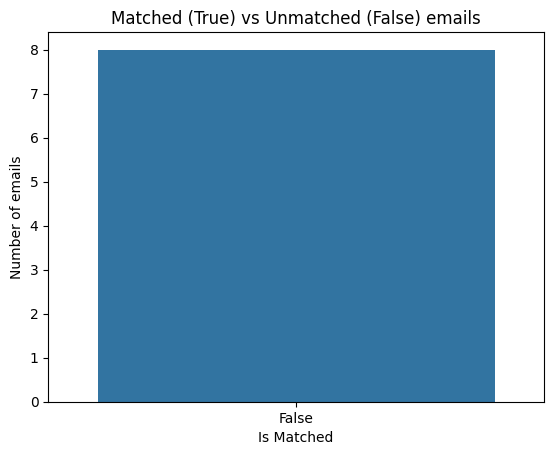

In [64]:
# after computing matches above, build simple metrics
out_df['top_score'] = out_df['matched_scores'].apply(lambda s: s[0] if isinstance(s, list) and s else 0)
out_df['is_matched'] = out_df['top_score'] >= 0.55

counts = out_df['is_matched'].value_counts()
sns.barplot(x=counts.index.astype(str), y=counts.values)
plt.title('Matched (True) vs Unmatched (False) emails')
plt.xlabel('Is Matched')
plt.ylabel('Number of emails')
plt.show()


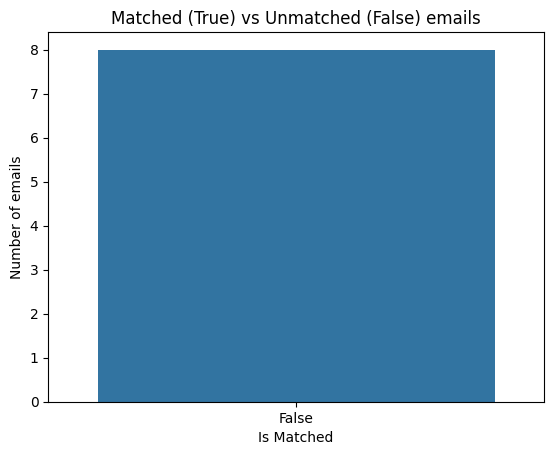

In [65]:
# after computing matches above, build simple metrics
out_df['top_score'] = out_df['matched_scores'].apply(lambda s: s[0] if isinstance(s, list) and s else 0)
out_df['is_matched'] = out_df['top_score'] >= 0.55

counts = out_df['is_matched'].value_counts()
sns.barplot(x=counts.index.astype(str), y=counts.values)
plt.title('Matched (True) vs Unmatched (False) emails')
plt.xlabel('Is Matched')
plt.ylabel('Number of emails')
plt.show()


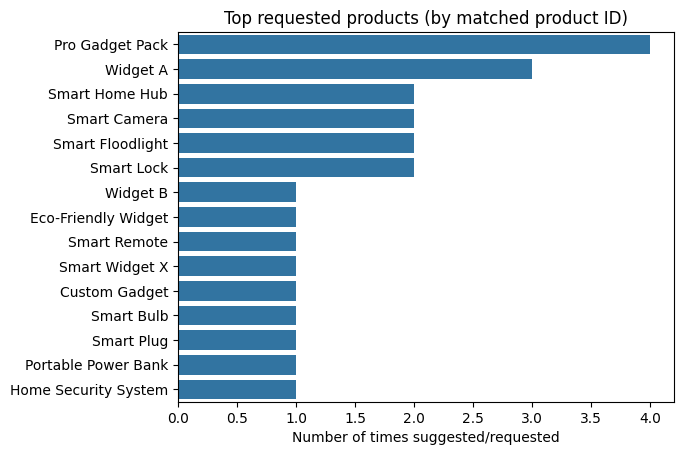

In [66]:
# explode matched_products
exploded = out_df.explode('matched_products')
top_requests = exploded['matched_products'].value_counts().head(20)
top_products = products.set_index('Product ID').loc[top_requests.index]
sns.barplot(x=top_requests.values, y=[str(s) for s in top_products['Name']])
plt.title('Top requested products (by matched product ID)')
plt.xlabel('Number of times suggested/requested')
plt.show()
